# Experiment III: Three-Way Comparison

Baseline DSM vs Lagrangian-constrained DSM vs FP-Diffusion (direct FPE residual regularization)

## Setup and Imports

In [1]:
import sys, logging, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
import pinn_sgm
pinn_sgm.setup_logging(logging.INFO)

from pinn_sgm.equations.merton import FokkerPlanckMertonND
from pinn_sgm.sgm.merton import MertonSDE
from pinn_sgm.sgm.trainer import DSMTrainer
from pinn_sgm.nets.mlp import MLP
from pinn_sgm.config import DSMConfig, ScorePINNConfig, TrainingConfig
from pinn_sgm.solvers.score_pinn_solver import ScorePINNSolver
from pinn_sgm.visualizations import setup_publication_style

device = torch.device("cpu")
dtype = torch.float32

setup_publication_style()
%config InlineBackend.figure_format = 'retina'

## Part 1: Model and Data

In [2]:
equation = FokkerPlanckMertonND(
    spatial_dim=1, mu=0.05, sigma=0.2, x0=0.0, device=device, dtype=dtype,
)
sde = MertonSDE(equation)
T = 1.0
N_DATA = 4000
x0_data = torch.zeros(N_DATA, 1, device=device, dtype=dtype)

## Part 2: Score-PINN (for Lagrangian constraint)

In [3]:
score_pinn_net = MLP(input_dim=2, output_dim=1, hidden_dims=[64, 64, 64], activation='tanh')

score_pinn_solver = ScorePINNSolver(
    equation=equation,
    score_network=score_pinn_net,
    config=ScorePINNConfig(
        n_collocation=10000, n_initial=1000, batch_size=256,
        x_range=(-1.0, 1.0), t_range=(0.0, 1.0), t_epsilon=0.1, use_hte=True,
    ),
    device='cpu',
)

pinn_history = score_pinn_solver.train(TrainingConfig(
    epochs=5000, learning_rate=1e-3, lr_decay_step=1000, lr_decay_rate=0.5, log_interval=1000,
))

def theory_score_fn(x, t):
    score_pinn_net.eval()
    with torch.no_grad():
        return score_pinn_net(torch.cat([x, t], dim=-1))


Epoch        Total        Initial      Residual     LR           Time        
------------------------------------------------------------------------
0/5000       2.0499e+04   2.0499e+04   3.4153e-05   1.0000e-03   11.35it/s   


1000/5000    7.5257e+03   7.5105e+03   1.5219e+01   5.0000e-04   14.76it/s   


2000/5000    4.5422e+03   4.5279e+03   1.4301e+01   2.5000e-04   14.72it/s   


3000/5000    3.6050e+03   3.5867e+03   1.8322e+01   1.2500e-04   14.83it/s   


4000/5000    3.0402e+03   3.0262e+03   1.4028e+01   6.2500e-05   14.74it/s   


------------------------------------------------------------------------
Training completed in 353.51s (5.89min)
Final: Total=2.8928e+03, Initial=2.8723e+03, Residual=2.0428e+01



## Part 3: FP-Diffusion: Score FPE residual as DSM regularizer

Compute the Score PDE residual of the learned score network and add it to the DSM loss. No separate Score-PINN needed.

In [4]:
def compute_fpe_residual(score_net, equation, x, t):
    """Compute ||∂s/∂t - ∇_x{L[s]}||² for a batch of (x, t) points."""
    x = x.detach().requires_grad_(True)
    t = t.detach().requires_grad_(True)

    s = score_net(torch.cat([x, t], dim=-1))  # [B, d]
    d = s.shape[-1]

    # ∂s/∂t
    s_t = []
    for i in range(d):
        g = torch.autograd.grad(s[:, i].sum(), t, create_graph=True, retain_graph=True)[0]
        s_t.append(g.squeeze(-1))
    s_t = torch.stack(s_t, dim=-1)  # [B, d]

    # L[s] for constant coefficients: ½∇·(Ds) + ½sᵀDs - fᵀs
    D = equation.D  # [d, d]
    f = equation.mu  # [d]
    Ds = torch.einsum('ij,bj->bi', D, s)  # [B, d]

    # ∇·(Ds) via autograd
    div_Ds = torch.zeros(x.shape[0], device=x.device)
    for j in range(d):
        g = torch.autograd.grad(Ds[:, j].sum(), x, create_graph=True, retain_graph=True)[0]
        div_Ds += g[:, j]

    L_s = 0.5 * div_Ds + 0.5 * (s * Ds).sum(dim=-1) - (f * s).sum(dim=-1)  # [B]

    # ∇_x{L[s]}
    grad_L = torch.autograd.grad(L_s.sum(), x, create_graph=True, retain_graph=True)[0]  # [B, d]

    residual = s_t - grad_L  # [B, d]
    return (residual ** 2).sum(dim=-1).mean()


def train_fp_diffusion(alpha, n_epochs=3000, seed=42):
    """Train DSM with direct FPE residual penalty (Lai et al. 2023)."""
    torch.manual_seed(seed)
    net = MLP(input_dim=2, output_dim=1, hidden_dims=[64, 64, 64], activation='tanh')

    optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

    cfg_T, cfg_t_eps, cfg_bs = T, 0.01, 512
    n_colloc = 500  # collocation points per batch for FPE residual

    history = {'dsm': [], 'fpe': [], 'total': []}

    for epoch in range(1, n_epochs + 1):
        # --- DSM loss (same as DSMTrainer) ---
        idx = torch.randint(0, N_DATA, (cfg_bs,))
        x0_batch = x0_data[idx]
        t_batch = torch.rand(cfg_bs, 1, device=device, dtype=dtype) * (cfg_T - cfg_t_eps) + cfg_t_eps

        with torch.no_grad():
            xt = sde.sample_marginal(x0_batch, t_batch)
            target = sde.marginal_score(xt, x0_batch, t_batch)

        s_pred = net(torch.cat([xt, t_batch], dim=-1))
        dsm_loss = ((s_pred - target) ** 2).sum(dim=-1).mean()

        # --- FPE residual loss ---
        if alpha > 0:
            x_col = torch.rand(n_colloc, 1, device=device, dtype=dtype) * 2 - 1  # [-1, 1]
            t_col = torch.rand(n_colloc, 1, device=device, dtype=dtype) * (cfg_T - cfg_t_eps) + cfg_t_eps
            fpe_loss = compute_fpe_residual(net, equation, x_col, t_col)
            total_loss = dsm_loss + alpha * fpe_loss
        else:
            fpe_loss = torch.tensor(0.0)
            total_loss = dsm_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        scheduler.step()

        history['dsm'].append(dsm_loss.item())
        history['fpe'].append(fpe_loss.item())
        history['total'].append(total_loss.item())

        if epoch % 500 == 0:
            msg = f"Epoch {epoch}/{n_epochs}  DSM={dsm_loss.item():.4e}"
            if alpha > 0:
                msg += f"  FPE={fpe_loss.item():.4e}"
            print(msg)

    return net, history

## Part 4: Network Training

In [5]:
def train_dsm(lambda_physics, n_epochs=3000, seed=42):
    torch.manual_seed(seed)
    net = MLP(input_dim=2, output_dim=1, hidden_dims=[64, 64, 64], activation='tanh')
    config = DSMConfig(
        batch_size=512, n_epochs=n_epochs, lr=1e-3, weight_decay=1e-5,
        lr_decay_step=500, lr_decay_gamma=0.5, T=T, t_eps=0.01,
        lambda_physics=lambda_physics, log_every=500,
    )
    trainer = DSMTrainer(
        sde=sde, score_network=net, config=config, device=device,
        theory_score_fn=theory_score_fn if lambda_physics > 0 else None,
    )
    history = trainer.train(x0_data)
    return net, history

# Method A: Baseline DSM (no constraint)
print("=== Baseline DSM ===")
net_baseline, hist_baseline = train_dsm(0.0)

# Method B: Lagrangian-constrained DSM (Chapter 4.1)
print("\n=== Lagrangian DSM (lambda=0.1) ===")
net_lagrangian, hist_lagrangian = train_dsm(0.1)

# Method C: FP-Diffusion (direct FPE residual, Lai et al.)
print("\n=== FP-Diffusion (alpha=0.1) ===")
net_fpdiff, hist_fpdiff = train_fp_diffusion(alpha=0.1)

=== Baseline DSM ===


2026-04-10 09:46:07 - pinn_sgm.sgm.trainer - INFO - Epoch 500/3000  DSM=5.5585e+00  LR=5.00e-04


2026-04-10 09:46:08 - pinn_sgm.sgm.trainer - INFO - Epoch 1000/3000  DSM=1.8248e+00  LR=2.50e-04


2026-04-10 09:46:09 - pinn_sgm.sgm.trainer - INFO - Epoch 1500/3000  DSM=8.9596e+00  LR=1.25e-04


2026-04-10 09:46:09 - pinn_sgm.sgm.trainer - INFO - Epoch 2000/3000  DSM=2.7689e+00  LR=6.25e-05


...

Epoch 1000/3000  DSM=3.0112e+01  FPE=3.9818e+00


Epoch 1500/3000  DSM=3.0715e+01  FPE=6.1287e+00


Epoch 2000/3000  DSM=9.6403e+00  FPE=6.5701e+01


Epoch 2500/3000  DSM=1.8270e+01  FPE=1.2454e+02


Epoch 3000/3000  DSM=1.1818e+01  FPE=1.3045e+00


## Part 5: Evaluation

In [6]:
eval_times = [0.10, 0.30, 0.50, 0.70, 1.00]
n_eval = 500
x_eval = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype).unsqueeze(-1)

def score_mse(net, t_val):
    t = torch.full((n_eval, 1), t_val, device=device, dtype=dtype)
    s_true = equation.analytical_score(x_eval, t)
    net.eval()
    with torch.no_grad():
        s_pred = net(torch.cat([x_eval, t], dim=-1))
    return ((s_pred - s_true) ** 2).mean().item()

methods = {
    'Baseline DSM': net_baseline,
    'Lagrangian': net_lagrangian,
    'FP-Diffusion': net_fpdiff,
}

mse = {name: [score_mse(net, t) for t in eval_times] for name, net in methods.items()}

print(f"{'t':>6s}", end="")
for name in methods:
    print(f" | {name:>14s}", end="")
print()
print("-" * (8 + 17 * len(methods)))
for i, t in enumerate(eval_times):
    print(f"{t:6.2f}", end="")
    for name in methods:
        print(f" | {mse[name][i]:14.4e}", end="")
    print()

     t |   Baseline DSM |     Lagrangian |   FP-Diffusion
-----------------------------------------------------------
  0.10 |     1.1403e+04 |     1.1511e+04 |     1.2936e+04
  0.30 |     2.1769e+02 |     2.2812e+02 |     4.1081e+02
  0.50 |     1.2090e+01 |     1.0910e+01 |     2.5206e+01
  0.70 |     1.1050e+01 |     1.0400e+01 |     2.6127e+00
  1.00 |     4.3054e-01 |     4.1857e-01 |     1.8597e-01


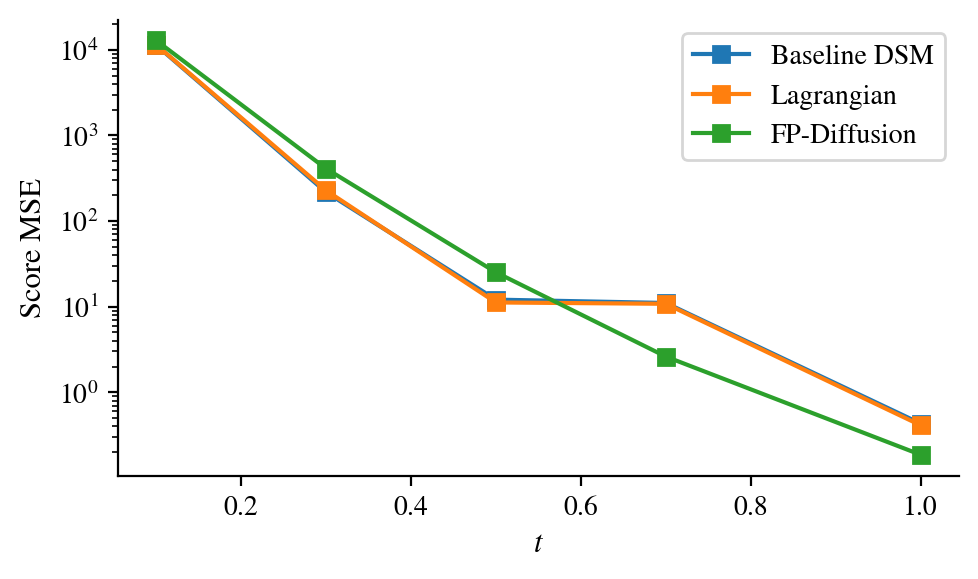

In [17]:
# Consistent colors for all plots in this section
method_colors = {
    'Baseline DSM': 'tab:blue',
    'Lagrangian': 'tab:orange',
    'FP-Diffusion': 'tab:green',
}

# Score MSE vs time
fig, ax = plt.subplots(figsize=(5, 3))
for name in methods:
    ax.semilogy(eval_times, mse[name], '-s', label=name, color=method_colors[name])
ax.set_xlabel("$t$"); ax.set_ylabel("Score MSE"); ax.legend()
plt.tight_layout()
plt.show()

# Score field at t=0.5 
t_plot = 0.5
t_eval_plot = torch.full((n_eval, 1), t_plot, device=device, dtype=dtype)
s_true = equation.analytical_score(x_eval, t_eval_plot).cpu().numpy()
x_np = x_eval.cpu().numpy()

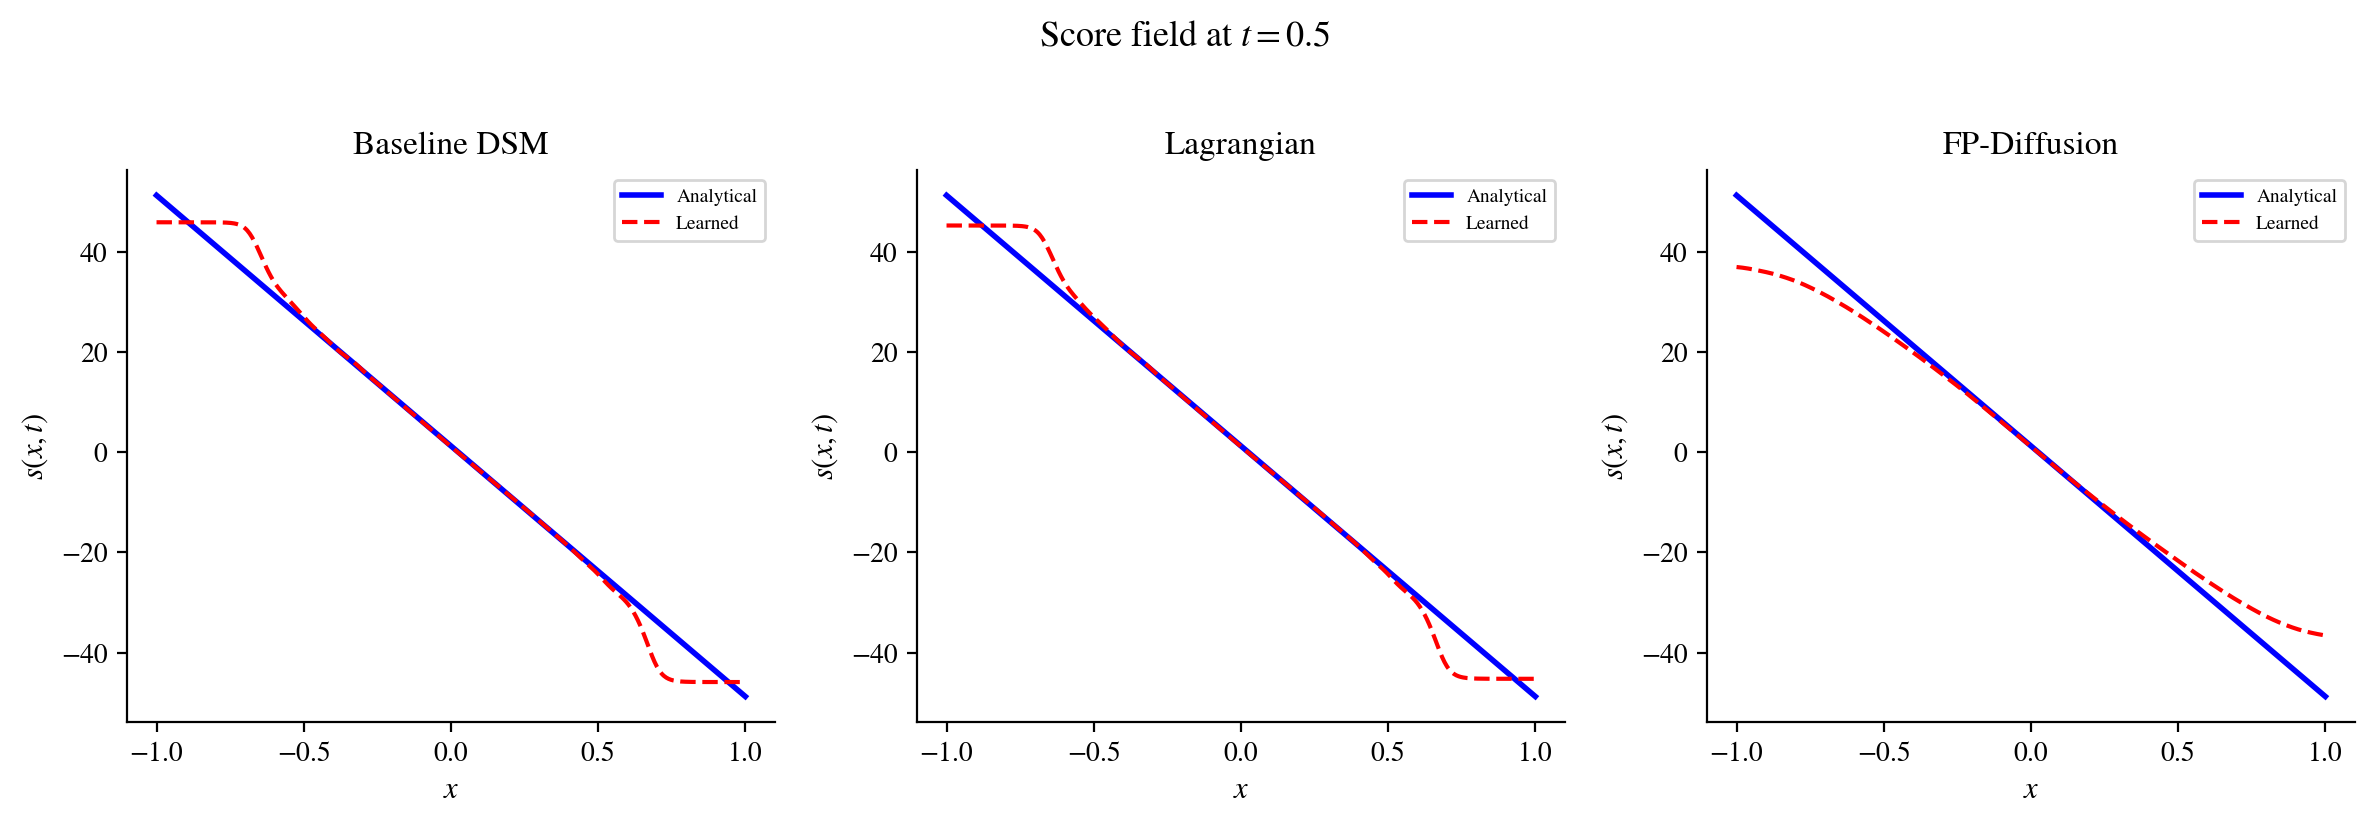

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, net) in zip(axes, methods.items()):
    net.eval()
    with torch.no_grad():
        s_pred = net(torch.cat([x_eval, t_eval_plot], dim=-1)).cpu().numpy()
    ax.plot(x_np, s_true, 'b-', lw=2, label="Analytical")
    ax.plot(x_np, s_pred, 'r--', lw=1.5, label="Learned")
    ax.set_title(name)
    ax.set_xlabel("$x$"); ax.set_ylabel("$s(x, t)$"); ax.legend(fontsize=7)
plt.suptitle(f"Score field at $t = {t_plot}$", y=1.02)
plt.tight_layout()
plt.show()

## Part 6: Generated Sample Histograms from Reverse SDE

Run the reverse SDE with each trained score network. Create a histogram from the resulting paths to approximate the generated sample distribution. 

2026-04-10 10:13:51 - pinn_sgm.sgm.sampler - INFO - Reverse SDE: generated 5000 samples (1D) with 200 steps, 1 corrector steps per step
2026-04-10 10:13:51 - pinn_sgm.sgm.sampler - INFO - Reverse SDE: generated 5000 samples (1D) with 200 steps, 1 corrector steps per step
2026-04-10 10:13:51 - pinn_sgm.sgm.sampler - INFO - Reverse SDE: generated 5000 samples (1D) with 200 steps, 1 corrector steps per step


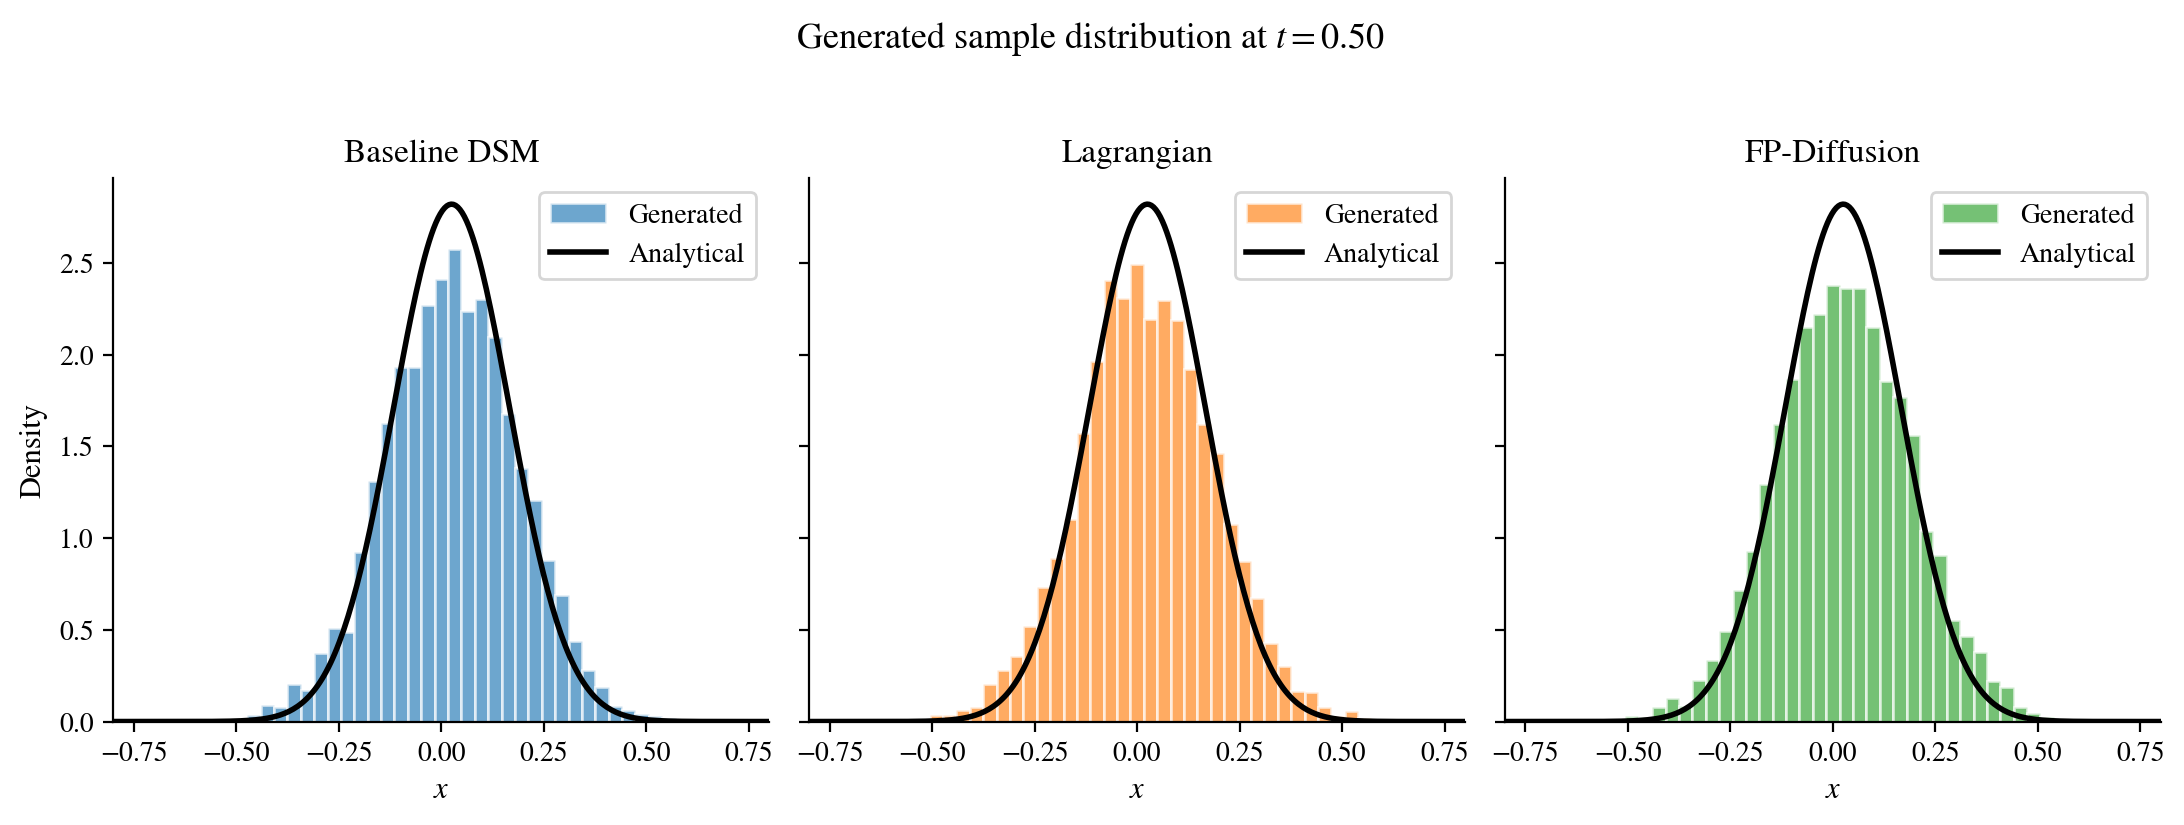

In [16]:
from pinn_sgm.sgm.sampler import ReverseDiffusionSampler
from scipy.stats import norm

# --- Sample initial states from the prior p_T = N(mu*T, sigma^2*T) ---
n_samples = 5000
t_eps = 0.01
mu_val = 0.05
sigma_val = 0.2
t_plot = 0.5  # time at which to compare distributions

torch.manual_seed(0)
x_T = torch.randn(n_samples, 1, dtype=dtype) * (sigma_val * T**0.5) + mu_val * T

# --- Run reverse SDE for each method, save trajectory ---
def make_score_fn(net):
    def score_fn(x, t):
        net.eval()
        with torch.no_grad():
            return net(torch.cat([x, t], dim=-1))
    return score_fn

n_steps = 200
trajectories = {}
for name, net in methods.items():
    sampler = ReverseDiffusionSampler(
        sde=sde, score_fn=make_score_fn(net),
        n_steps=n_steps, n_corrector_steps=1, corrector_step_size=0.01,
        t_eps=t_eps, device=device,
    )
    traj = sampler.sample(x_T.clone(), T=T, return_trajectory=True)  # [B, n_steps+1, 1]
    trajectories[name] = traj[:, :, 0].cpu().numpy()

# --- Extract samples at t = t_plot ---
# Time grid of the sampler goes from T down to t_eps (descending)
time_grid = np.linspace(T, t_eps, n_steps + 1)
idx_plot = np.argmin(np.abs(time_grid - t_plot))
actual_t = time_grid[idx_plot]

# --- Analytical density at that time: N(mu*t, sigma^2*t) ---
true_mean = mu_val * actual_t
true_std = sigma_val * np.sqrt(actual_t)
x_grid = np.linspace(-0.8, 0.8, 300)
true_density = norm.pdf(x_grid, loc=true_mean, scale=true_std)

# --- Plot: three panels, one per method, using the same colors as the MSE plot ---
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
bins = np.linspace(-0.8, 0.8, 50)

for ax, (name, traj) in zip(axes, trajectories.items()):
    samples = traj[:, idx_plot]
    ax.hist(samples, bins=bins, density=True, alpha=0.65, color=method_colors[name], edgecolor='white', label='Generated')
    ax.plot(x_grid, true_density, 'k-', linewidth=2, label='Analytical')
    ax.set_title(name)
    ax.set_xlabel('$x$')
    ax.legend()
    ax.set_xlim(-0.8, 0.8)

axes[0].set_ylabel('Density')
plt.suptitle(rf"Generated sample distribution at $t = {actual_t:.2f}$", y=1.02)
plt.tight_layout()
plt.show()